# ChatGPT Camera Reasoning Loop

Workflow:
1. Copy `.env.example` to `.env` in the project root and fill in your `OPENAI_API_KEY`.
2. Run **Setup** and **Initialize** cells once.
3. Display the current screenshot and prompt (optional — just for visibility).
4. Run the **Ask ChatGPT** cell — it sends the prompt + screenshot to the OpenAI API and applies the returned action automatically.
5. Repeat step 4 until ChatGPT returns `STOP`.

In [28]:
print("Hello world")

Hello world


In [29]:
import sys, os
# Add project root so `camera_reasoning` is importable when running from notebooks/
sys.path.insert(0, os.path.abspath('..'))

from camera_reasoning import CameraReasoningSession
from IPython.display import Image, display

## Initialize Session
Edit the paths and parameters below to match your data.

In [33]:
session = CameraReasoningSession(
    raw_path="../data/vis_male_128x256x256_uint8.raw",
    dimensions=(128, 256, 256),
    scalar_type="uint8",
    use_volume_rendering=True,  # transfer function (see DEFAULT_OPACITY_POINTS/DEFAULT_COLOR_POINTS
                                # in camera_reasoning/session.py, tuned for this dataset) instead of
                                # a fixed isovalue isosurface.
    enable_smoothing=True,
    output_dir="../output",
    target_description=(
        "rendering of a human skull in right-side profile,"
    ),
    # target_image_path="../data/skull.png",  # optional
    # simple_spatial_knowledge_path="../data/simple_foot_spatial_spec.json",  # optional spatial grounding
)

session.initialize()
session.render_and_save()
session.write_llm_prompt()

Scene initialized (volume rendering, transfer function). dims=(128, 256, 256).


'You are ChatGPT, acting as a camera-reasoning assistant for a 3D VTK scene.\n\nYour job is to compare the current render with the target view and choose exactly\none next camera action.\n\nImportant image-group distinction:\n- reference_items are stable reference views used as visual anchors;\n- candidate_items are one-step action renders generated from the current camera.\nNever interchange these roles.\n\nUse comparative hypothesis reasoning rather than committing to the first plausible\nview interpretation. Evaluate every allowed action before selecting one.\nCandidate-action reasoning must be image-first: visual differences are evidence;\naction names and descriptions are identifiers only.\n\nRules:\n- You are NOT allowed to invent raw camera coordinates.\n- You are NOT allowed to output arbitrary angles.\n- You are NOT allowed to generate VTK code.\n- You MUST choose exactly one final action from the allowed action list below.\n- View candidates MUST use exact names from canonica

## View Current Screenshot and Prompt

In [31]:
# Start from the same camera position as view_000 (the root node) in
# reference_views_relative/camera_nodes.json, instead of VTK's auto-framed
# ResetCamera() default.
import json
from camera_reasoning.camera_state import set_camera_state

_nodes = json.loads(open("../reference_views_relative/camera_nodes.json").read())
_view_000 = next(n for n in _nodes if n["node_id"] == "view_000")

set_camera_state(session._renderer.GetActiveCamera(), _view_000["camera"])
session._renderer.ResetCameraClippingRange()

session.render_and_save()
session.write_llm_prompt()
print("Camera state set to view_000.")

Camera state set to view_000.


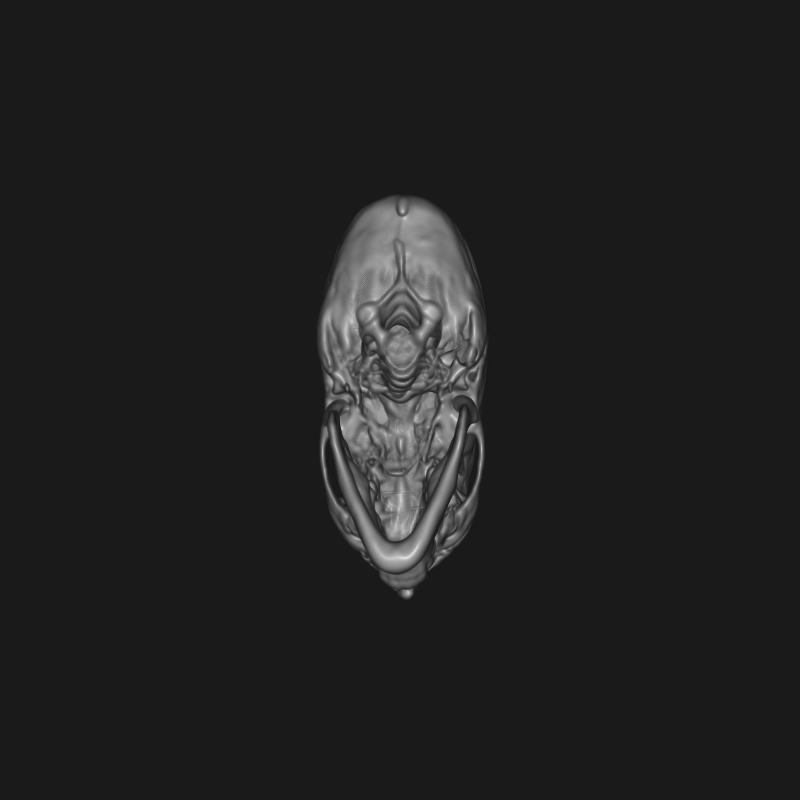

You are ChatGPT, acting as a camera-reasoning assistant for a 3D VTK scene.

Your job is to compare the current render with the target view and choose exactly
one next camera action.

Important image-group distinction:
- reference_items are stable reference views used as visual anchors;
- candidate_items are one-step action renders generated from the current camera.
Never interchange these roles.

Use comparative hypothesis reasoning rather than committing to the first plausible
view interpretation. Evaluate every allowed action before selecting one.
Candidate-action reasoning must be image-first: visual differences are evidence;
action names and descriptions are identifiers only.

Rules:
- You are NOT allowed to invent raw camera coordinates.
- You are NOT allowed to output arbitrary angles.
- You are NOT allowed to generate VTK code.
- You MUST choose exactly one final action from the allowed action list below.
- View candidates MUST use exact names from canonical_views.
- Every allo

In [34]:
display(Image("../output/screenshots/latest.png"))
print(open("../output/llm_prompt.txt").read())

## Ask ChatGPT

Two ways to use this:

- **Quick loop** (below): auto-generates the prompt from the current camera state and applies whatever action comes back. Good for just running the loop.
- **Prompt experimentation** (further down): lets you edit the prompt text yourself before sending it, and inspect the reply before deciding whether to apply it. Good for testing prompt/reasoning changes.

In [12]:
# session.ask_chatgpt_and_process()

# display(Image("../output/screenshots/latest.png"))
# print(open("../output/llm_prompt.txt").read())

## Run Multiple Iterations

Runs the quick loop repeatedly instead of re-running the cell above by hand. Stops early if `STOP` comes back.

In [9]:
import json
from camera_reasoning.spatial_knowledge import extract_diagnosis_sections
from camera_reasoning.image_view_matcher import ImageViewMatcher
from camera_reasoning.text_view_matcher import TextViewMatcher
from camera_reasoning.frozen_reference_alignment import verify_observation_against_embeddings

# Built once, reused every iteration below — only the query (current screenshot /
# current observation text) gets re-encoded per iteration, not the reference database.
# Cache paths are scoped under reference_views_relative/ (not the shared top-level
# reference_embeddings.pkl / reference_text_embeddings.pkl) so switching back to
# ../reference_views later can't silently load a stale cache built from this bank.
image_matcher = ImageViewMatcher(reference_dir="../reference_views_relative", cache_path="../reference_views_relative/image_embeddings.pkl")
image_matcher.build_index()
text_matcher = TextViewMatcher(descriptions_path="../reference_views_relative/view_descriptions.json", cache_path="../reference_views_relative/text_embeddings.pkl")
text_matcher.build_index()

# reference_items: injected into every ask_chatgpt() call below so the model sees
# each reference image immediately followed by its own description (image,
# description, image, description, ...) rather than images and text separately.
# Built once here (the graph bank doesn't change mid-loop), reused every iteration.
_nodes = json.loads(open("../reference_views_relative/camera_nodes.json").read())
_descriptions = {d["node_id"]: d["description"] for d in json.loads(open("../reference_views_relative/view_descriptions.json").read())}
reference_items = [
    (n["node_id"], "../" + n["image_path"], _descriptions[n["node_id"]])
    for n in _nodes
    if n["node_id"] in _descriptions
]
print(f"Injecting {len(reference_items)} reference images+descriptions every iteration: {[label for label, _, _ in reference_items]}")

num_iterations = 20

for i in range(num_iterations):
    print(f"=== Iteration {i + 1}/{num_iterations} ===", flush=True)

    # Capture the screenshot path BEFORE applying any action this iteration —
    # process_chatgpt_response() below re-renders and overwrites latest.png, so
    # verification must run first, against the exact same image the model saw
    # (and described in its "Visual observation"), not the post-rotation result.
    current_image_path = "../output/screenshots/latest.png"

    response = session.ask_chatgpt(reference_items=reference_items)
    print(response, flush=True)

    # observation_text = extract_diagnosis_sections(response).get("visual_observation")
    # if observation_text:
    #     verification = verify_observation_against_embeddings(
    #         current_image_path, observation_text, image_matcher, text_matcher, top_k=5
    #     )
    #     print("Top-3 similar image views (BEFORE this iteration's camera action):", flush=True)
    #     for m in verification["image_top_k"][:3]:
    #         print(f"    {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}", flush=True)
    #     print("Top-3 similar description views:", flush=True)
    #     for m in verification["text_top_k"][:3]:
    #         print(f"    {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}", flush=True)
    # else:
    #     print("No 'Visual observation' section found in response; skipping verification.", flush=True)

    # NOW apply the action — this re-renders and overwrites latest.png with the new view.
    action = session.process_chatgpt_response(response)

    display(Image("../output/screenshots/latest.png"))
    if action == "STOP":
        break

[image_view_matcher] Loaded 18 cached reference embeddings from ../reference_views_relative/image_embeddings.pkl
[text_view_matcher] Loaded 18 cached reference text embeddings from ../reference_views_relative/text_embeddings.pkl
Injecting 18 reference images+descriptions every iteration: ['view_000', 'view_001', 'view_002', 'view_003', 'view_004', 'view_005', 'view_006', 'view_007', 'view_008', 'view_009', 'view_010', 'view_011', 'view_012', 'view_013', 'view_014', 'view_015', 'view_016', 'view_017']
=== Iteration 1/20 ===


APIConnectionError: Connection error.

## Experiment with a Custom Prompt

1. Start from the auto-generated prompt (or write your own from scratch).
2. Edit `custom_prompt` however you like — reword the rules, add few-shot examples, change the target description, etc.
3. Run the next cell to send it and see the raw reply, without applying anything yet.
4. If you're happy with the result, run the final cell to apply the returned action.

In [ ]:
# Start from the auto-generated prompt, then edit freely.
custom_prompt = session.write_llm_prompt()
print(custom_prompt)

In [ ]:
# Edit custom_prompt above (or reassign it directly here), then send it without applying the result.
response = session.ask_chatgpt(prompt=custom_prompt)
print(response)

In [ ]:
# Happy with the response? Apply it.
session.process_chatgpt_response(response)

display(Image("../output/screenshots/latest.png"))

## Frozen-Reference-Embedding Alignment (Experimental)

An alternative to the text-based loop above. Instead of reasoning from scratch every
iteration, it:
1. Picks the single most visually similar reference view **once**, via image
   embeddings (`reference_views/`), and freezes it as the alignment target.
2. Every iteration: the LLM describes the current screenshot and compares it against
   that same frozen target (never re-picks a new target), then chooses a camera action.
3. Also cross-checks the LLM's own description against the reference database via
   both image embeddings and text embeddings — printing the top-3 matches (with
   scores) from each, every iteration, so you can spot when the LLM's words disagree
   with what the embeddings say.

Requires `reference_views/` + `reference_views/view_descriptions.json` to already
exist (see `examples/generate_reference_views.py` and
`camera_reasoning/view_description_generator.py` if you haven't generated them yet).

In [ ]:
from camera_reasoning.frozen_reference_alignment import run_camera_reasoning_pipeline

result = run_camera_reasoning_pipeline(
    session,
    num_iterations=5,
    use_frozen_reference_alignment=True,
    references_dir="../reference_views",
    dry_run=False,  # set True to freeze the target + analyze/reason once WITHOUT moving the camera
)

display(Image("../output/screenshots/latest.png"))
print("\nFrozen target view:", result["alignment_target_reference"]["view_name"])
print("Applied actions:", result["applied_actions"])

## Visual-Rollout Camera-Action Selection (Experimental)

A different alternative to the text-based loop above. Instead of picking a camera
action from action *names* + a single current screenshot, every iteration:
1. Renders one candidate image per available camera action, each starting from the
   exact current camera state (never cumulative with each other, and the active
   camera is restored after every candidate — see `render_candidate_rollouts()`).
2. Sends the current image, the target description/image, and every candidate
   image immediately followed by its own action description to the LLM.
3. Asks the LLM to select the action whose *rendered outcome* is closest to the
   target — explicitly judged from the rendered pixels, not from keywords in the
   action names — then applies only that one selected action.

The reasoning schema mirrors the exhaustive per-action evaluation from the
text-based loop above (`current_visual_observation`, `target_difference`, and a
per-candidate `observed_visual_change` / `relation_to_target` / `history_check` /
`verdict` / `justification`) — merged so both loops reason the same way, but this
one grounds every candidate in an actual rendered image instead of an imagined one.

`ACTION_SUBSET = None` evaluates every action in `VALID_ACTIONS` each iteration
(~22 candidates + STOP), which is a much larger/slower/costlier API call per
iteration than the loops above. Set it to a smaller set (as below) to try this out
more cheaply first.

Every iteration's candidates, full evaluation, and applied action are logged to
`../output/rollout_traces/rollout_NNN.json` for debugging.

In [ ]:
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from camera_reasoning.visual_rollout_agent import run_visual_rollout_alignment_loop

def display_rollout_candidates(trace_path: str):
    """Show every candidate rollout image from one iteration's trace, labeled with
    its action name + verdict, with the selected candidate marked. Passed as
    on_iteration_end below, so this pops up live after each iteration finishes —
    not only once the whole loop is done."""
    trace = json.loads(open(trace_path).read())
    candidates = trace["candidates"]
    selection = trace["selection"]
    verdicts = {c["action"]: c.get("verdict") for c in selection.get("candidate_evaluation", [])}
    selected_action = selection.get("selected_action")

    n = len(candidates)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, c in enumerate(candidates):
        img = mpimg.imread(c["image_path"])
        axes[i].imshow(img)
        axes[i].axis("off")
        marker = "\n★ SELECTED" if c["action"] == selected_action else ""
        axes[i].set_title(f"{c['action']}\n{verdicts.get(c['action'], '')}{marker}", fontsize=9)
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Iteration {trace['iteration']} — candidate rollouts")
    plt.tight_layout()
    plt.show()

# Start small/cheap. Set to None to evaluate every action in VALID_ACTIONS instead.
ACTION_SUBSET = {
    "AZIMUTH_LEFT_COARSE", "AZIMUTH_RIGHT_COARSE",
    "ELEVATION_UP_COARSE", "ELEVATION_DOWN_COARSE",
    "ZOOM_IN", "ZOOM_OUT", "STOP",
}

rollout_result = run_visual_rollout_alignment_loop(
    session,
    max_iterations=10,
    action_subset=ACTION_SUBSET,
    on_iteration_end=display_rollout_candidates,
)

display(Image("../output/screenshots/latest.png"))
print("\nApplied actions:", rollout_result["applied_actions"])

In [ ]:
# Post-hoc replay: re-display every iteration's candidates from the last run,
# in case you want to scroll back through the whole run again without re-running it.
import glob

trace_files = sorted(glob.glob("../output/rollout_traces/rollout_*.json"))
print(f"Found {len(trace_files)} rollout trace(s) from the last run.")
for trace_path in trace_files:
    display_rollout_candidates(trace_path)

## Old Agent + Rendered Candidate Images

Same reasoning/prompt as **Run Multiple Iterations** above — `prompt_writer.py` and
`session.py` are completely unmodified, still producing the exact same free-form
"Visual diagnosis" → exhaustive action-by-action evaluation (`effect` /
`relation_to_target` / `predicted_visual_change` / `history_check` / `verdict` /
`justification`) → "Next action" format.

The only addition: before each `ask_chatgpt()` call, every candidate action is
actually rendered first (reusing `render_candidate_rollouts()`, unmodified, from
the visual-rollout section above) and attached via `reference_items`, so the model
sees real candidate renders alongside its usual text prompt — instead of only
ever seeing the single current screenshot and imagining `predicted_visual_change`.

`ACTION_SUBSET = None` renders every action in `VALID_ACTIONS` each iteration; set
a smaller set (as below) to try this out more cheaply first.

Loaded 18 graph-bank reference items: ['view_000', 'view_001', 'view_002', 'view_003', 'view_004', 'view_005', 'view_006', 'view_007', 'view_008', 'view_009', 'view_010', 'view_011', 'view_012', 'view_013', 'view_014', 'view_015', 'view_016', 'view_017']
=== Iteration 1/20 ===
Rendered 9 candidate images: ['AZIMUTH_LEFT_COARSE', 'AZIMUTH_RIGHT_COARSE', 'ELEVATION_DOWN_COARSE', 'ELEVATION_UP_COARSE', 'ROLL_CCW_90', 'ROLL_CW_90', 'STOP', 'ZOOM_IN', 'ZOOM_OUT']
Visual observation:
The current render shows a human skull from a perspective that reveals extensive internal architecture and fragmented bone surfaces. The skull occupies the central frame with complex, heavily textured surfaces showing numerous foramina, processes, and irregular fragmented edges throughout. The maxilla with visible dentition appears in the lower left region, displaying individual teeth arranged in their dental arch. The cranial vault appears as a smooth curved surface on the left side of the frame. The right and 

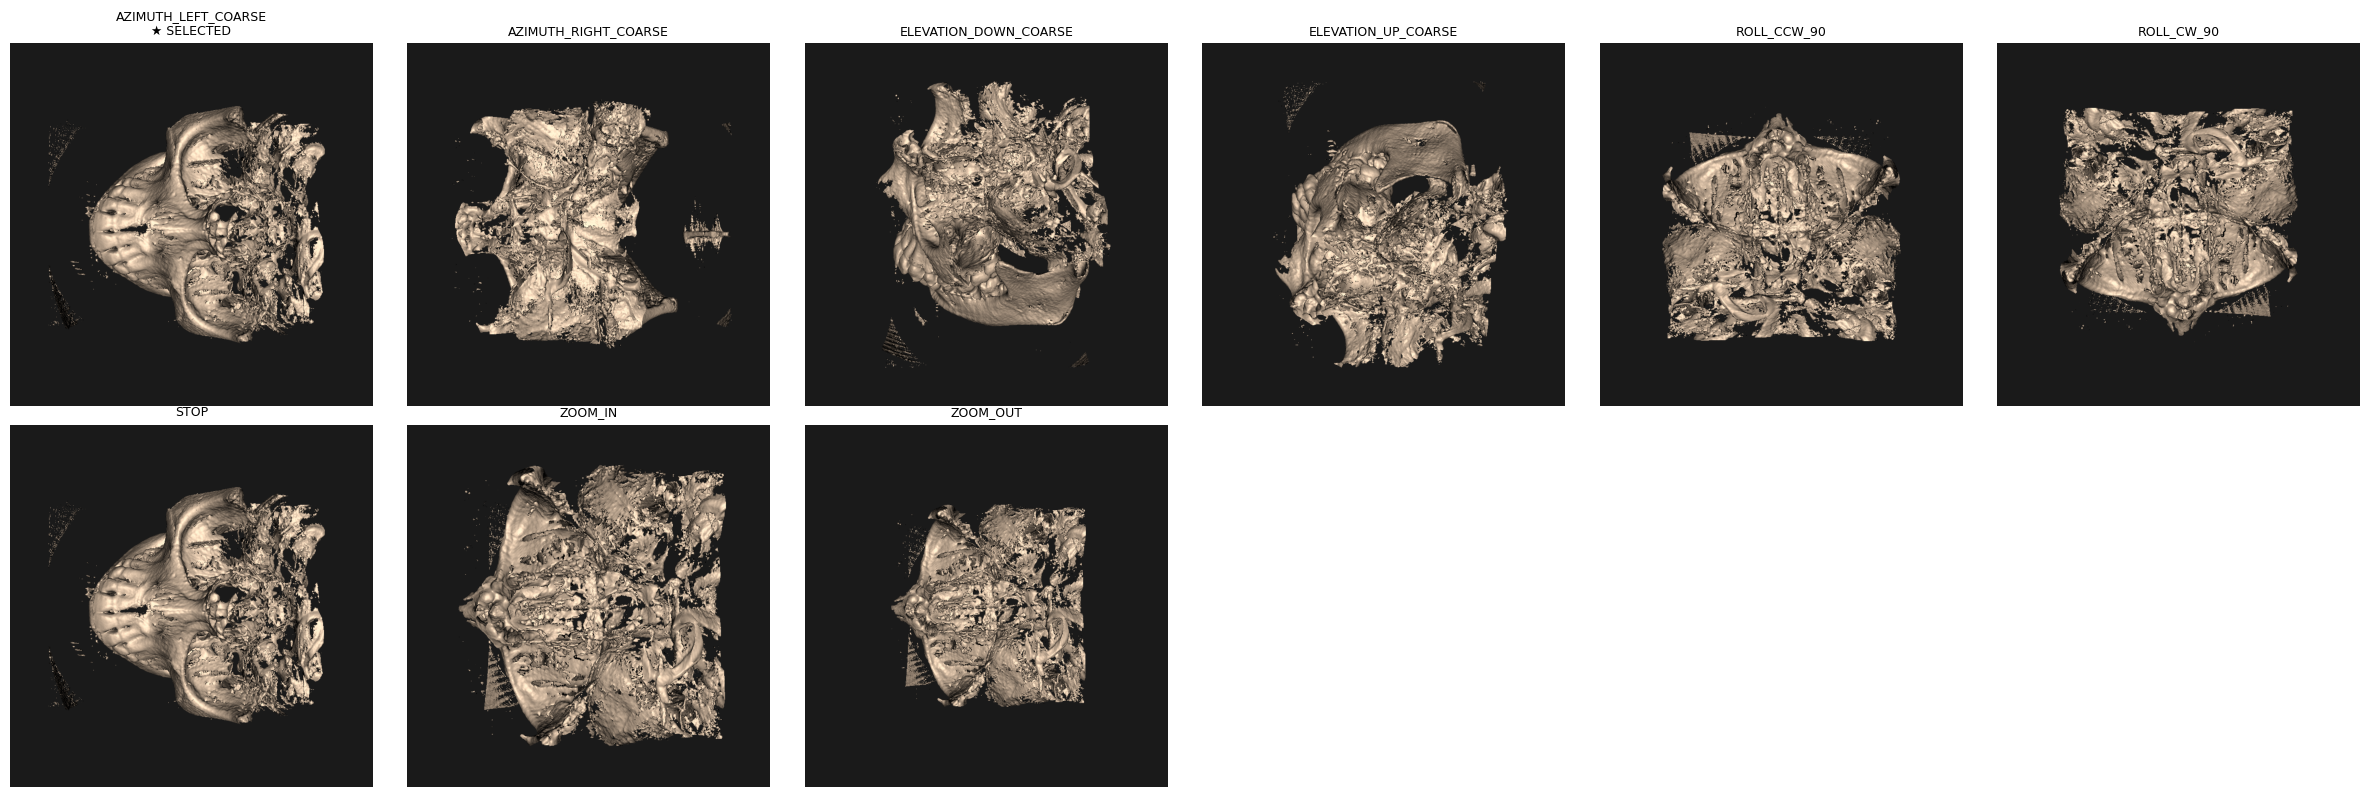

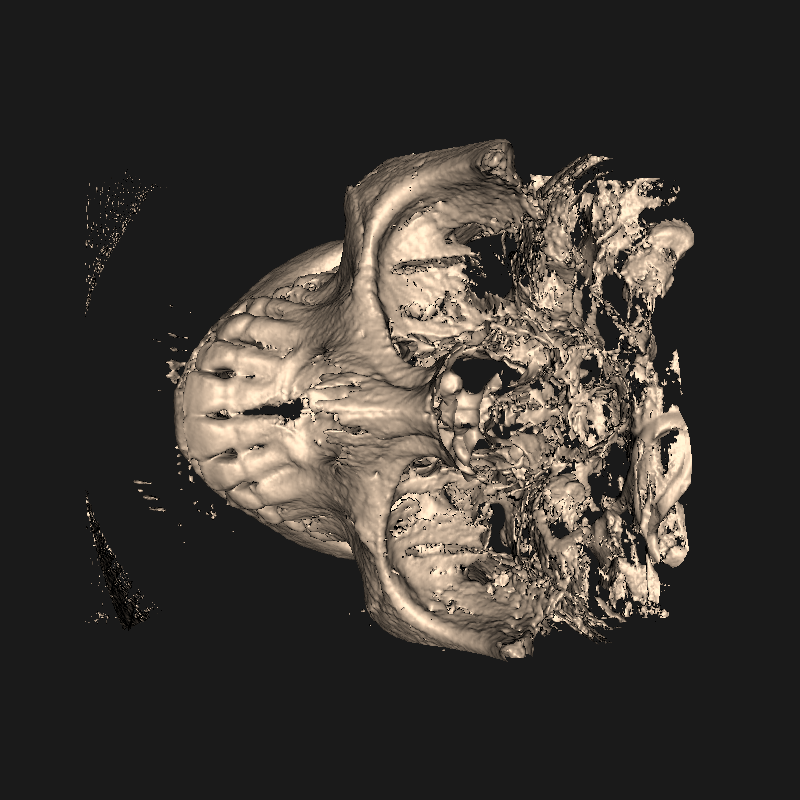

=== Iteration 2/20 ===
Rendered 9 candidate images: ['AZIMUTH_LEFT_COARSE', 'AZIMUTH_RIGHT_COARSE', 'ELEVATION_DOWN_COARSE', 'ELEVATION_UP_COARSE', 'ROLL_CCW_90', 'ROLL_CW_90', 'STOP', 'ZOOM_IN', 'ZOOM_OUT']
Visual observation:
The current render shows a skull viewed from an oblique antero-lateral perspective. The smooth, rounded cranial vault occupies the left side of the frame. The facial skeleton is visible centrally and toward the right, with the maxilla and upper dental arcade clearly displayed showing individual teeth arranged in a curved arch on the left-center area. The right side of the frame shows extensive fragmented bone texture with irregular surfaces, including orbital structures, nasal cavity, and heavily disrupted cranial base elements. There is significant depth variation, with the smooth cranial vault receding on the left while fragmented facial and base structures project forward on the right. Small bone fragments and rendering artifacts scatter around the periphery.

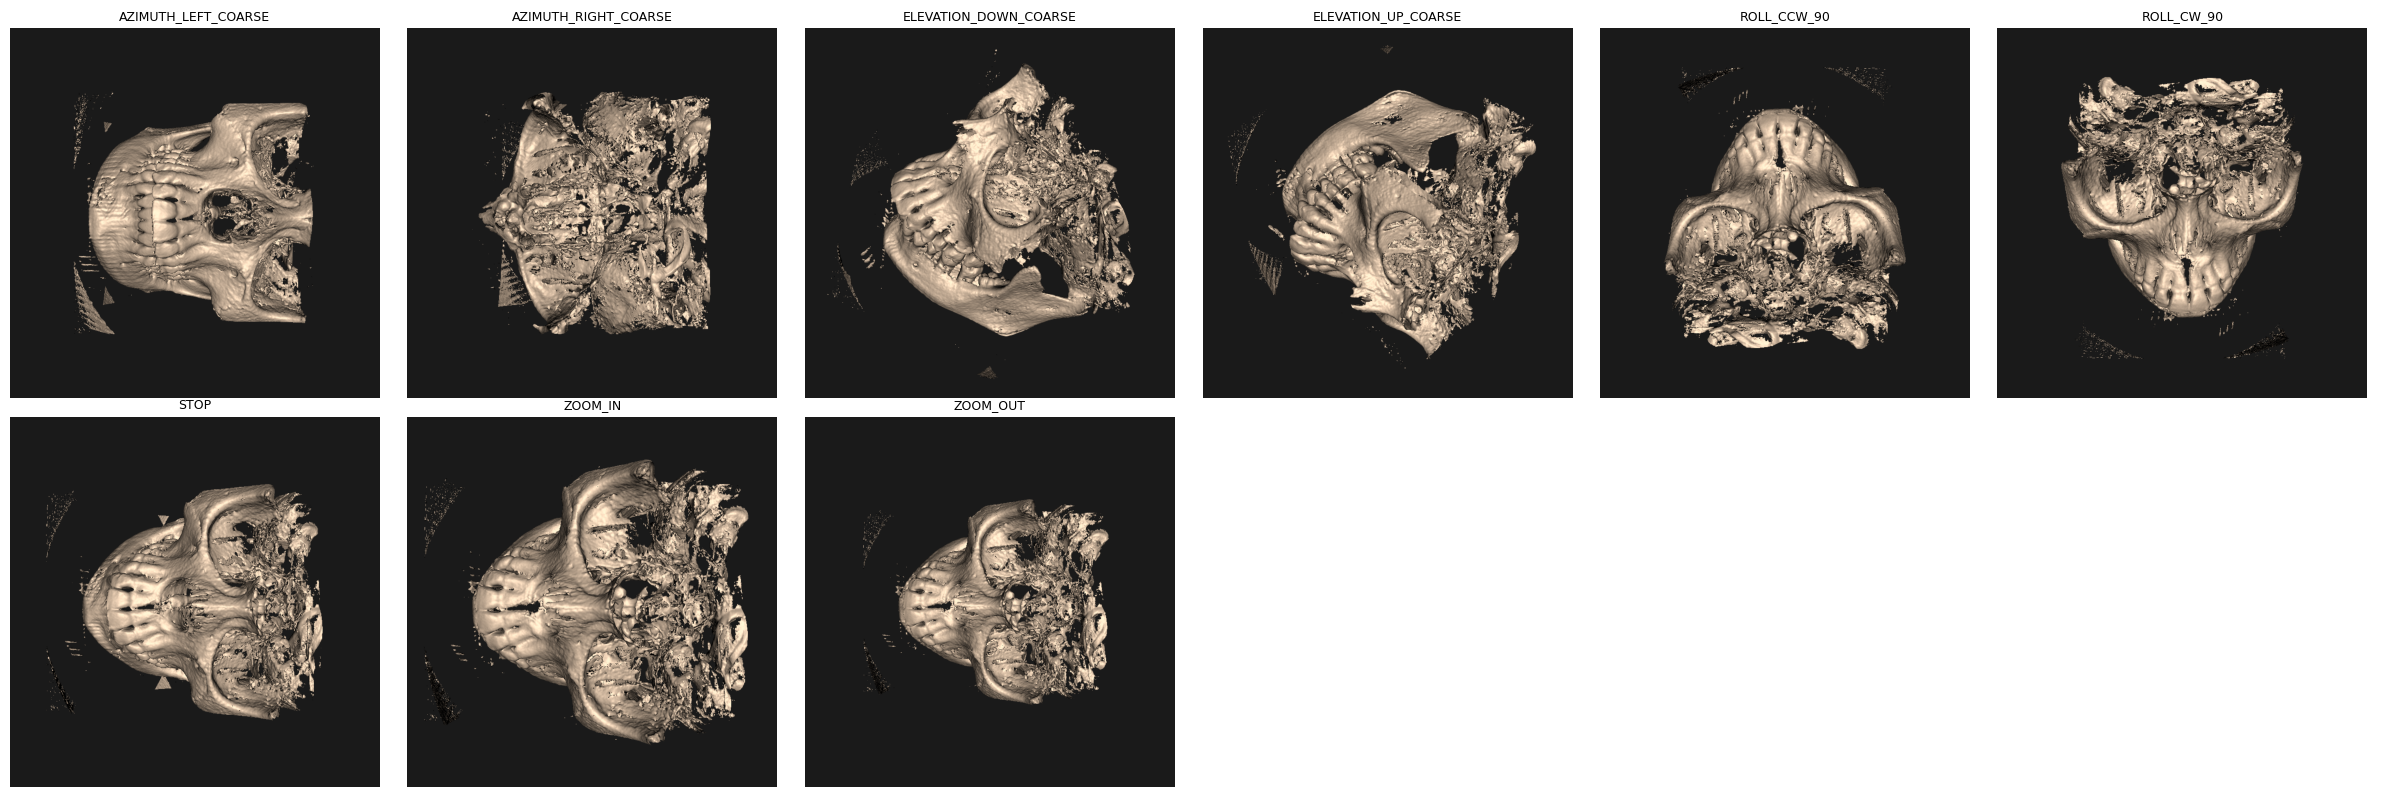

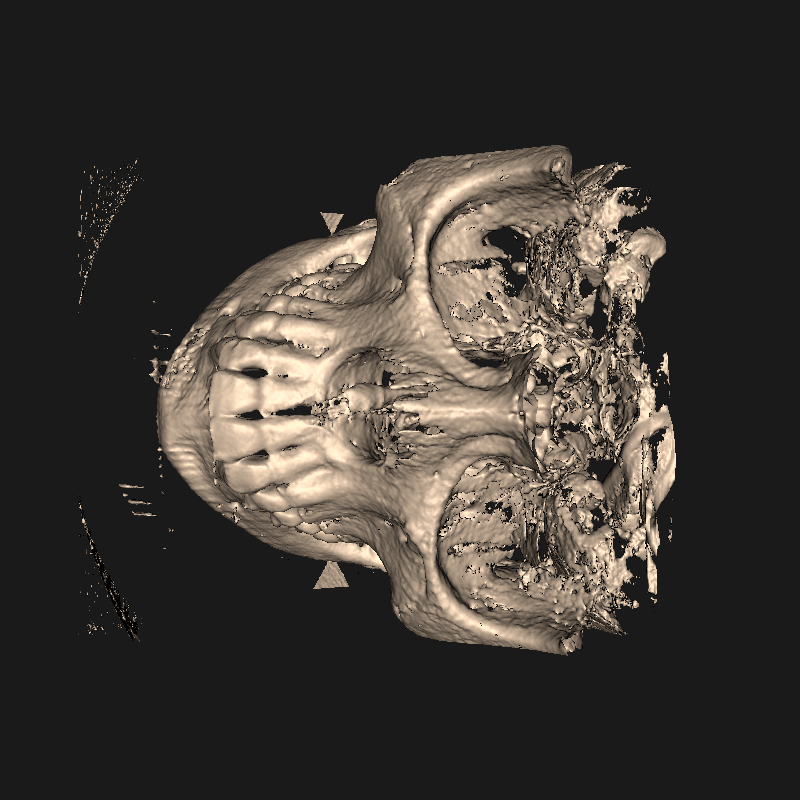

=== Iteration 3/20 ===
Rendered 9 candidate images: ['AZIMUTH_LEFT_COARSE', 'AZIMUTH_RIGHT_COARSE', 'ELEVATION_DOWN_COARSE', 'ELEVATION_UP_COARSE', 'ROLL_CCW_90', 'ROLL_CW_90', 'STOP', 'ZOOM_IN', 'ZOOM_OUT']
Visual observation:
The current render displays a human skull in an oblique three-quarter orientation. The smooth, rounded cranial vault occupies the left portion of the frame with visible suture lines. In the center-left, the maxilla is visible with a complete upper dental arcade showing individual teeth arranged in their characteristic arch. The right side of the frame shows extensive fragmentation, revealing complex internal cranial architecture including orbital structures, nasal cavity, and cranial base elements with a porous, lace-like texture. The zygomatic arch extends laterally. A mandible fragment is visible in the lower left. The skull appears to be viewed from a position that shows both the lateral aspect of the cranium and an anterolateral view of the facial skeleton, 

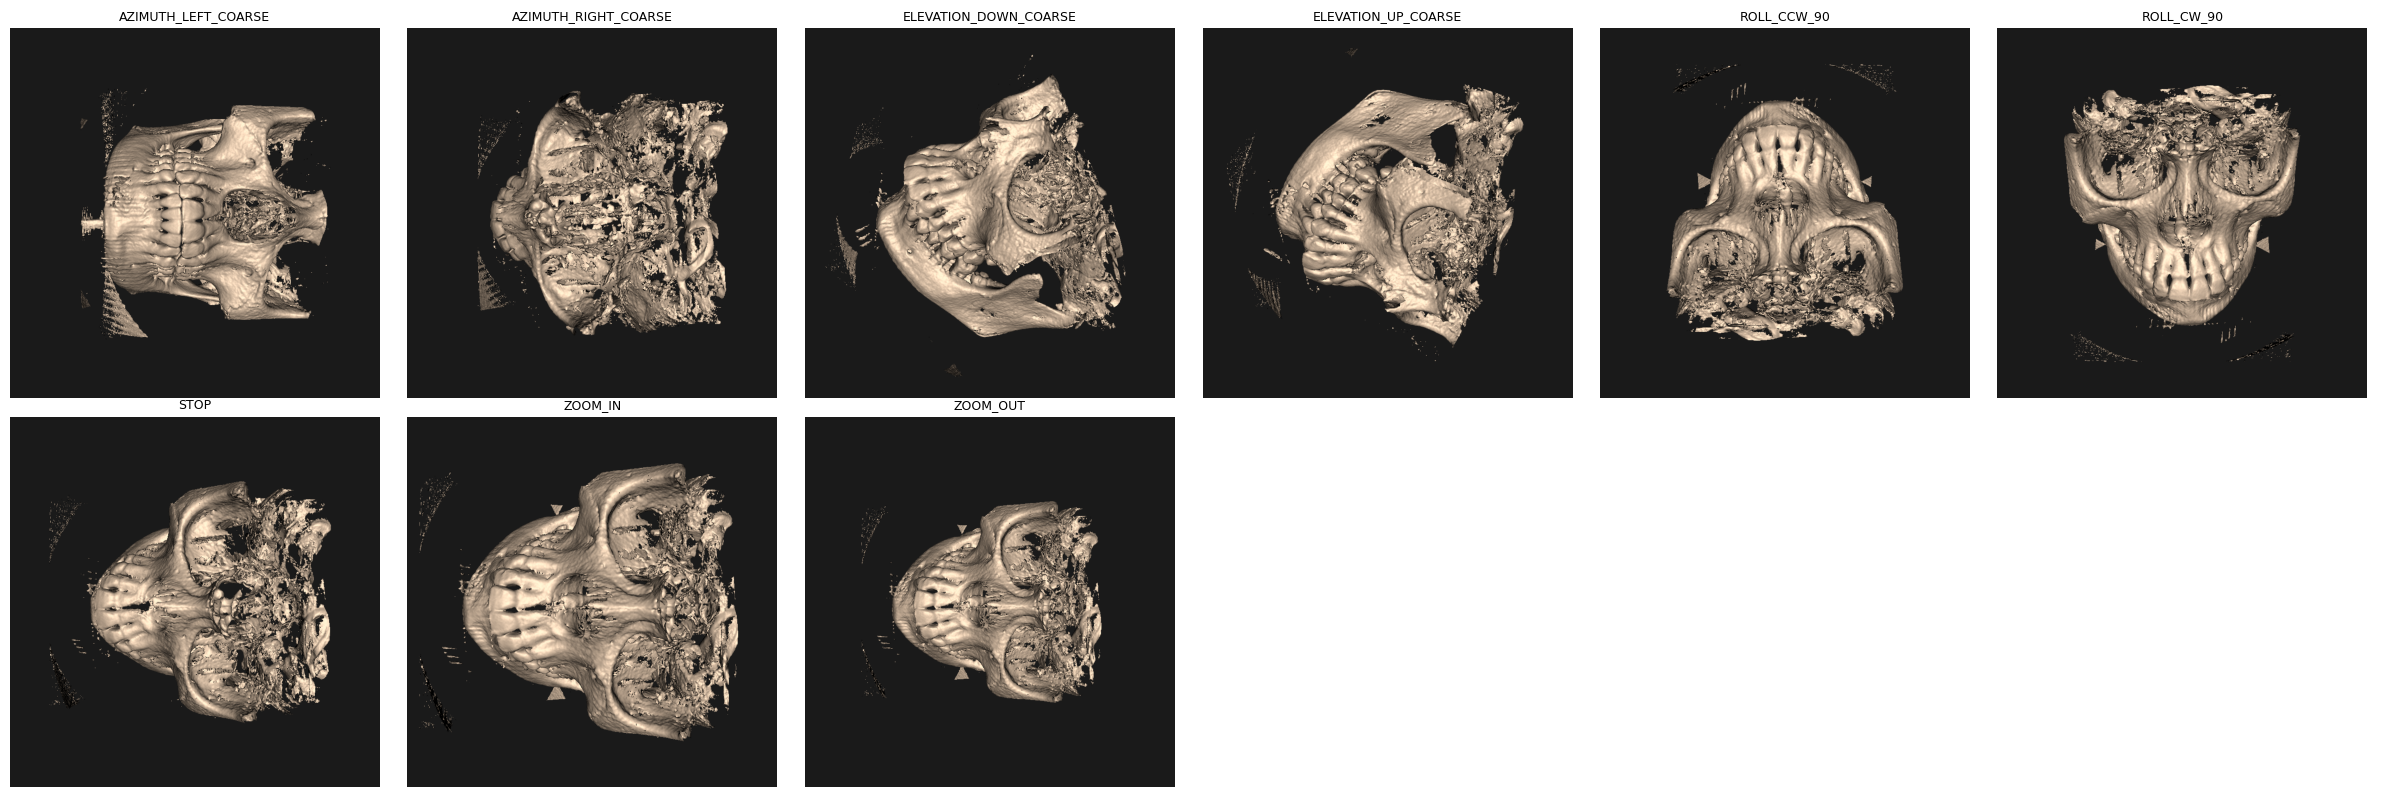

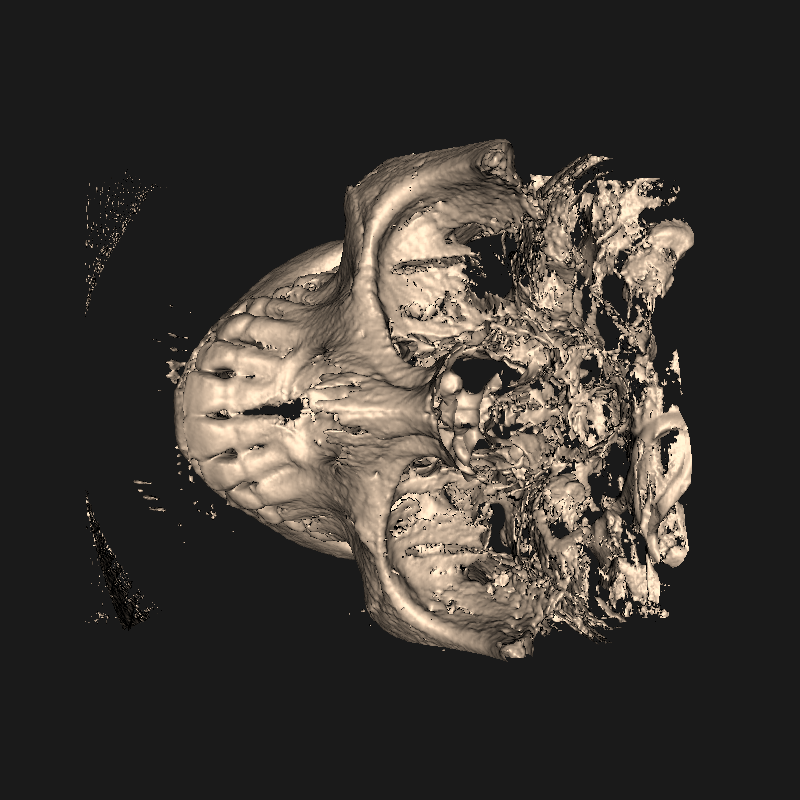

=== Iteration 4/20 ===
Rendered 9 candidate images: ['AZIMUTH_LEFT_COARSE', 'AZIMUTH_RIGHT_COARSE', 'ELEVATION_DOWN_COARSE', 'ELEVATION_UP_COARSE', 'ROLL_CCW_90', 'ROLL_CW_90', 'STOP', 'ZOOM_IN', 'ZOOM_OUT']


KeyboardInterrupt: 

In [ ]:
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from camera_reasoning import ACTION_DESCRIPTIONS
from camera_reasoning.visual_rollout_agent import render_candidate_rollouts

def display_candidate_images(rollouts, selected_action=None):
    """Show every candidate rollout image for one iteration, labeled by action
    name, with the one the LLM selected (if known yet) marked."""
    n = len(rollouts)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, r in enumerate(rollouts):
        img = mpimg.imread(r["image_path"])
        axes[i].imshow(img)
        axes[i].axis("off")
        marker = "\n★ SELECTED" if r["action"] == selected_action else ""
        axes[i].set_title(f"{r['action']}{marker}", fontsize=9)
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# reference_items: the graph-bank (reference_views_relative/) images+descriptions —
# built once here, reused every iteration, since the bank itself doesn't change.
_nodes = json.loads(open("../reference_views_relative/camera_nodes.json").read())
_descriptions = {d["node_id"]: d["description"] for d in json.loads(open("../reference_views_relative/view_descriptions.json").read())}
reference_items = [
    (n["node_id"], "../" + n["image_path"], _descriptions[n["node_id"]])
    for n in _nodes
    if n["node_id"] in _descriptions
]
print(f"Loaded {len(reference_items)} graph-bank reference items: {[label for label, _, _ in reference_items]}")

# Start small/cheap. Set to None to render every action in VALID_ACTIONS instead.
ACTION_SUBSET = {
    "AZIMUTH_LEFT_COARSE", "AZIMUTH_RIGHT_COARSE",
    "ELEVATION_UP_COARSE", "ELEVATION_DOWN_COARSE", "ROLL_CCW_90", "ROLL_CW_90", "STOP",
}

num_iterations = 20
applied_actions = []

for i in range(num_iterations):
    print(f"=== Iteration {i + 1}/{num_iterations} ===", flush=True)

    # candidate_reference_items: rendered fresh every iteration, one per candidate
    # action from the CURRENT camera state (never accumulates, restores the camera
    # afterward — see render_candidate_rollouts()).
    current_image_path = session.render_and_save()
    rollouts = render_candidate_rollouts(session, current_image_path, action_subset=ACTION_SUBSET)
    print(f"Rendered {len(rollouts)} candidate images: {[r['action'] for r in rollouts]}", flush=True)

    candidate_reference_items = [
        (r["action"], r["image_path"], ACTION_DESCRIPTIONS.get(r["action"], ""))
        for r in rollouts
    ]

    # prompt=None -> session.write_llm_prompt() runs exactly as before (unchanged
    # reasoning/format); reference_items + candidate_reference_items are both
    # attached — the graph bank first, then this iteration's rendered candidates.
    response = session.ask_chatgpt(reference_items=reference_items, candidate_items=candidate_reference_items)
    print(response, flush=True)

    # Same old parsing/application path as every other cell in this notebook.
    action = session.process_chatgpt_response(response)
    applied_actions.append(action)

    print(f"Candidates this iteration (★ = selected: {action}):", flush=True)
    display_candidate_images(rollouts, selected_action=action)

    display(Image("../output/screenshots/latest.png"))
    if action == "STOP":
        break

print("\nApplied actions:", applied_actions)

## Blind Visual-Rollout Camera-Action Selection (Experimental)

A structurally label-blind variant of the Visual-Rollout section above. The LLM
never sees a real camera-action name anywhere — only opaque, randomly generated
candidate IDs (regenerated and reshuffled every iteration) paired with their
rendered images and one identical, non-descriptive caption. This removes any
chance of the model reasoning from words like "left"/"right"/"up"/"down" instead
of the actual visual differences between renders.

Every iteration renders **7 candidates**:
- 4 scalable directions with COARSE/MEDIUM/FINE variants (azimuth left/right,
  elevation up/down), each rendered ONLY at COARSE.
- 3 fixed, single-outcome candidates with no magnitude variants to interpolate:
  `AZIMUTH_RIGHT_180`, `ELEVATION_UP_180`, and now **STOP** — STOP's "render" is
  simply the current image, so the LLM diagnoses it exactly like every other
  candidate (blind to the fact that it represents "no change") rather than STOP
  being a separate keyword it can invoke directly.

Then a three-pass pipeline decides the action:
1. **Pass 1 (LLM, diagnosis + reference grounding)** — produces a structured
   JSON diagnosis of the target, current render, and every candidate
   (`view_description`, `comparison_to_target`, `similarity_score`,
   `confidence`). It never selects a candidate or a magnitude itself. Reference
   grounding is now the LLM's own visual judgment too: every reference-view
   image is attached directly, and for each image the LLM reports
   `closest_reference_id` (or null), a categorical `reference_match_quality`
   (exact/close/partial/distant/unclear), and a required
   `reference_match_differences` explanation of what's different when it isn't
   an exact match. No image embeddings or CLIP model are used anywhere in this
   pipeline — an earlier revision used deterministic CLIP retrieval instead,
   but it proved unreliable on this dataset (near-identical renders that
   differ only in fine rotation), so it was replaced with this LLM-judged
   approach.
2. **Pass 2 (pure Python, no LLM)** — deterministically ranks every candidate
   (including the STOP candidate) by `similarity_score` → `confidence` →
   `reference_match_confidence` (a fixed number mapped from the LLM's
   `reference_match_quality`). STOP can win this ranking on its own merits if
   it's diagnosed as already closest to the target. Pass 2 also still has a
   separate, independent fixed-threshold STOP check that can short-circuit
   before ranking even runs — both paths can produce STOP, which is fine,
   they're not mutually exclusive.
3. **Pass 3 (LLM, magnitude only)** — only called for the 4 scalable candidates;
   skipped for the 3 fixed ones including STOP (their magnitude is accepted but
   ignored, since there's no smaller/larger version to interpolate to). Sees
   only the current render, target, and the already-selected candidate — it
   cannot reconsider Python's selection, only estimate `full` / `reduced` /
   `minimal`.

Python then privately resolves the selection + magnitude into a real,
`VALID_ACTIONS`-checked action name (e.g. `AZIMUTH_LEFT_MEDIUM`, `STOP`) — the
LLM never outputs a real action name at any point.

Every iteration's blind candidates, both LLM responses, the Python selection
reasoning, and the privately resolved final action are logged to
`../output/blind_rollout_traces/blind_rollout_NNN.json` for debugging (the real
action mapping is stored there for YOUR inspection only — it's never sent to the
LLM).

Loaded 24 medical skull reference images and labels.

[blind_visual_rollout_agent] Iteration 0
[blind_visual_rollout_agent] Prepared 7 blind candidates (shuffled, private mapping not logged): ['CANDIDATE_8BD3X', 'CANDIDATE_3KC0Z', 'CANDIDATE_FZPME', 'CANDIDATE_X64P9', 'CANDIDATE_GJYSA', 'CANDIDATE_7BGBL', 'CANDIDATE_WCZ3F']
[blind_visual_rollout_agent] PASS 1 — VISUAL DIAGNOSIS
```json
{
  "target": {
    "view_description": "The target image shows a human skull in right lateral (side) profile. The entire right side of the skull is visible, including the right lateral surface of the cranium, the right zygomatic arch, the right maxilla and mandible with teeth visible in profile, the right orbit, and the right temporal bone. The frontal bone curves away to the left, and the occipital bone curves away posteriorly. The mandible is in articulation, and the teeth are shown in lateral occlusion.",
    "closest_reference_id": "skull_001",
    "reference_match_quality": "exact",
    "reference_

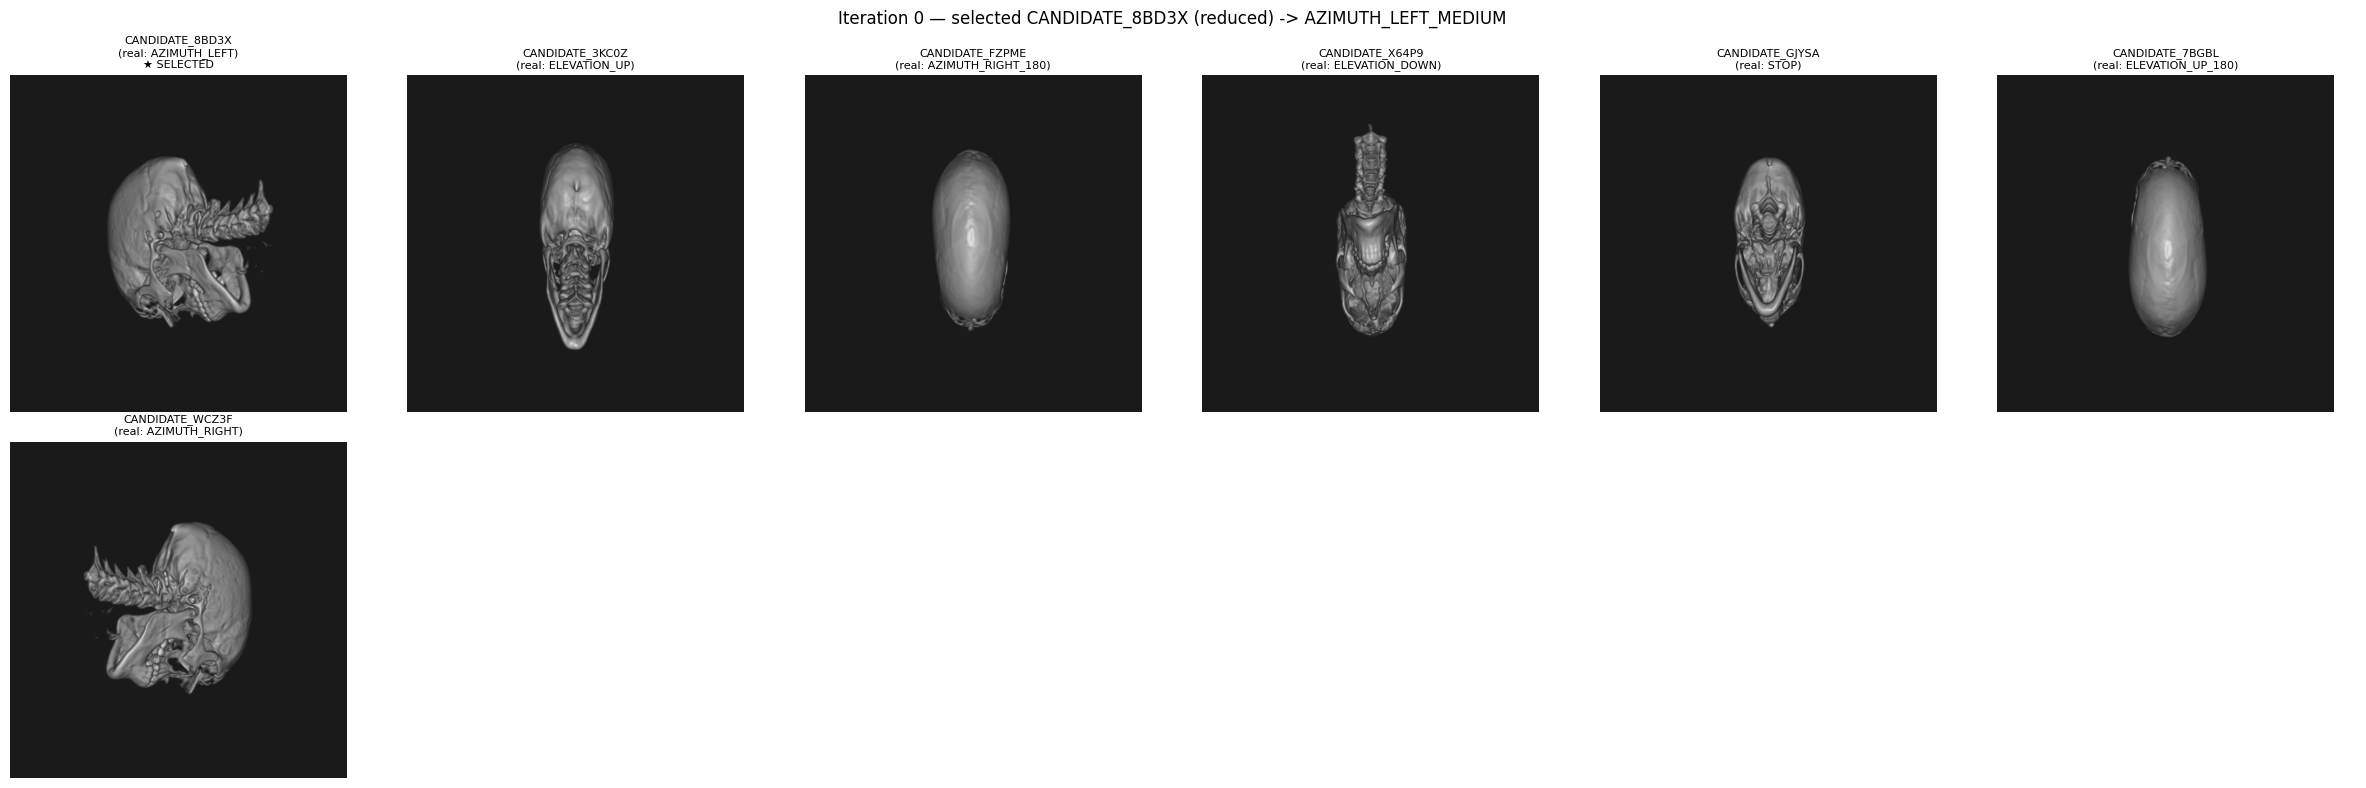


[blind_visual_rollout_agent] Iteration 1
[blind_visual_rollout_agent] Prepared 7 blind candidates (shuffled, private mapping not logged): ['CANDIDATE_KRG1P', 'CANDIDATE_YZFGN', 'CANDIDATE_S34MA', 'CANDIDATE_VFP0B', 'CANDIDATE_K3XE6', 'CANDIDATE_6Q2JJ', 'CANDIDATE_QV050']
[blind_visual_rollout_agent] PASS 1 — VISUAL DIAGNOSIS
```json
{
  "target": {
    "view_description": "The target shows a human skull in right lateral profile. The right side of the skull is fully visible, showing the temporal region, zygomatic arch, maxilla with teeth, mandible with teeth, orbit, and the lateral surface of the cranium. The face is oriented to the right of the frame, with the posterior cranium visible on the left side of the composition.",
    "closest_reference_id": "skull_001",
    "reference_match_quality": "exact",
    "reference_match_differences": "No meaningful difference observed. The target matches the canonical right lateral view of the skull shown in the reference."
  },
  "current": {
   

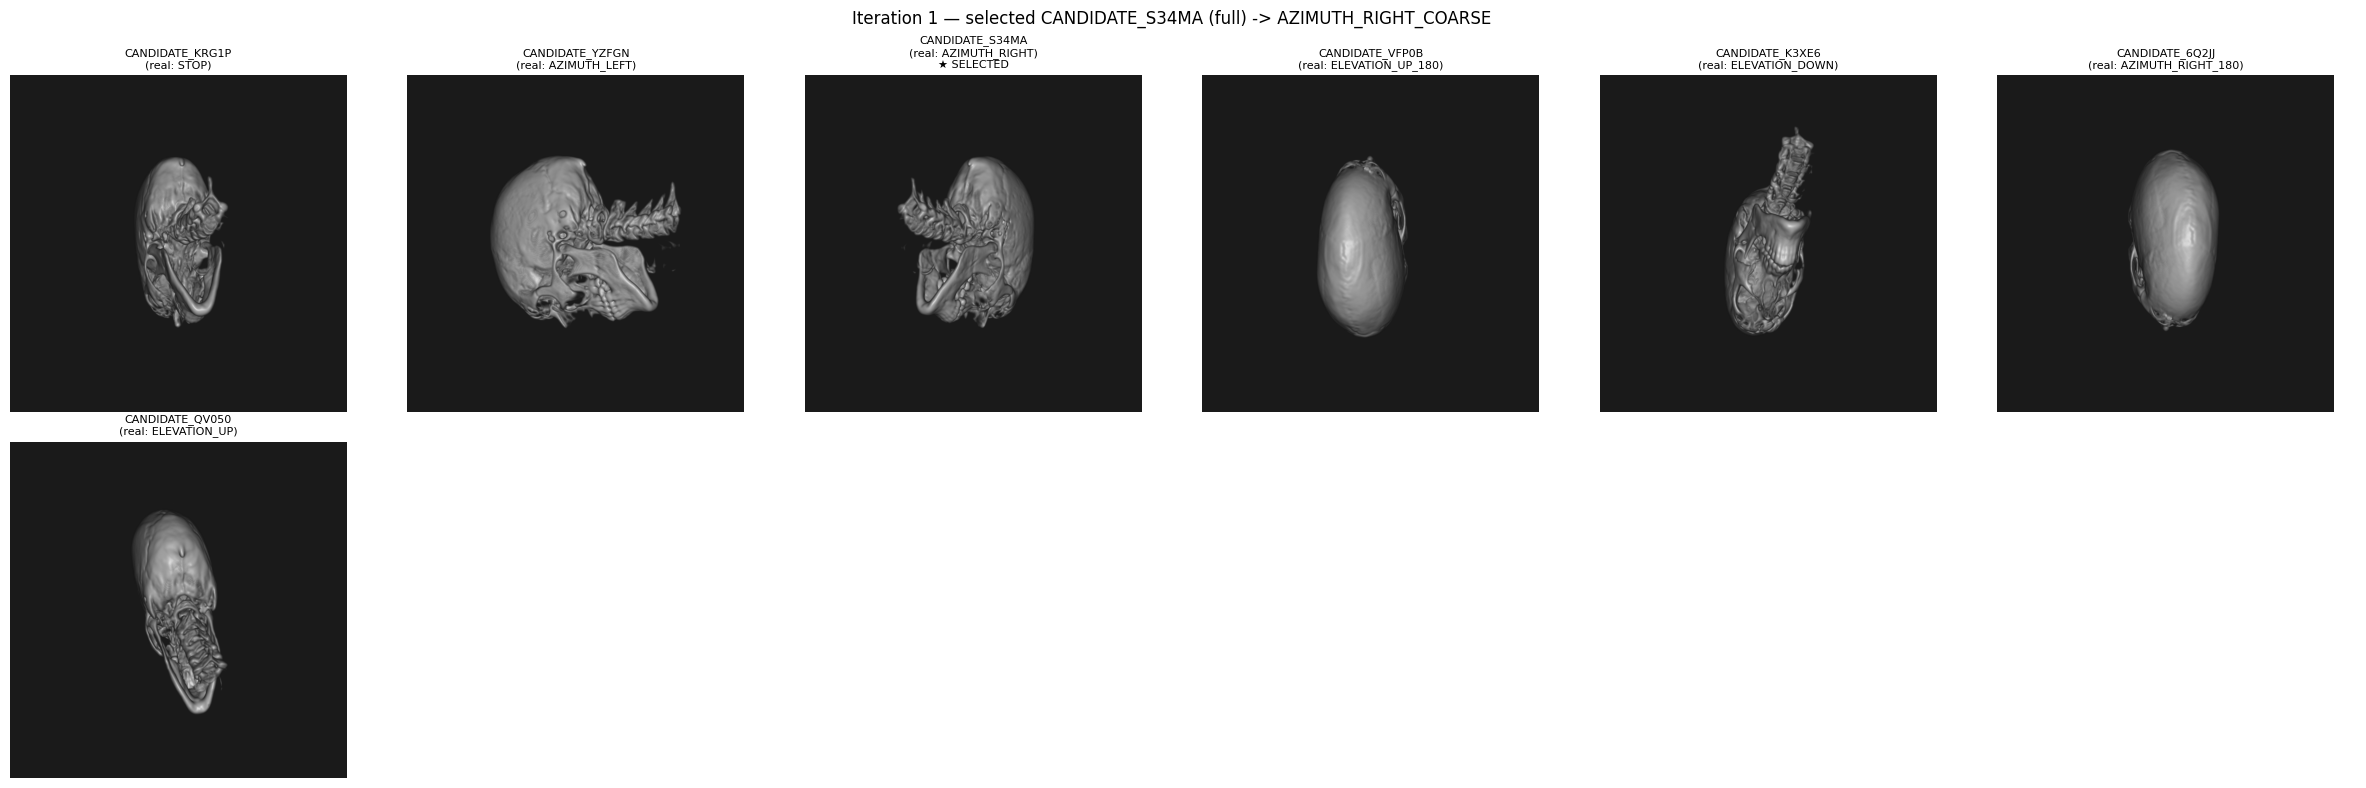


[blind_visual_rollout_agent] Iteration 2
[blind_visual_rollout_agent] Prepared 7 blind candidates (shuffled, private mapping not logged): ['CANDIDATE_Y35R6', 'CANDIDATE_ZYQOG', 'CANDIDATE_BUUO7', 'CANDIDATE_5JS8A', 'CANDIDATE_PCZO1', 'CANDIDATE_5UEZ6', 'CANDIDATE_9O0KF']
[blind_visual_rollout_agent] PASS 1 — VISUAL DIAGNOSIS
```json
{
  "target": {
    "view_description": "The target shows a human skull in right-side profile. The entire right lateral surface is visible, including the zygomatic arch, temporal region, and mandible in lateral view. The cranial vault curves smoothly from front to back. The eye orbit, nasal opening, and maxilla are seen from the side. The teeth are visible in profile along the jaw line. The occipital region is visible at the rear.",
    "closest_reference_id": "skull_001",
    "reference_match_quality": "exact",
    "reference_match_differences": "No meaningful difference observed. The target matches the canonical right lateral view of the skull with the s

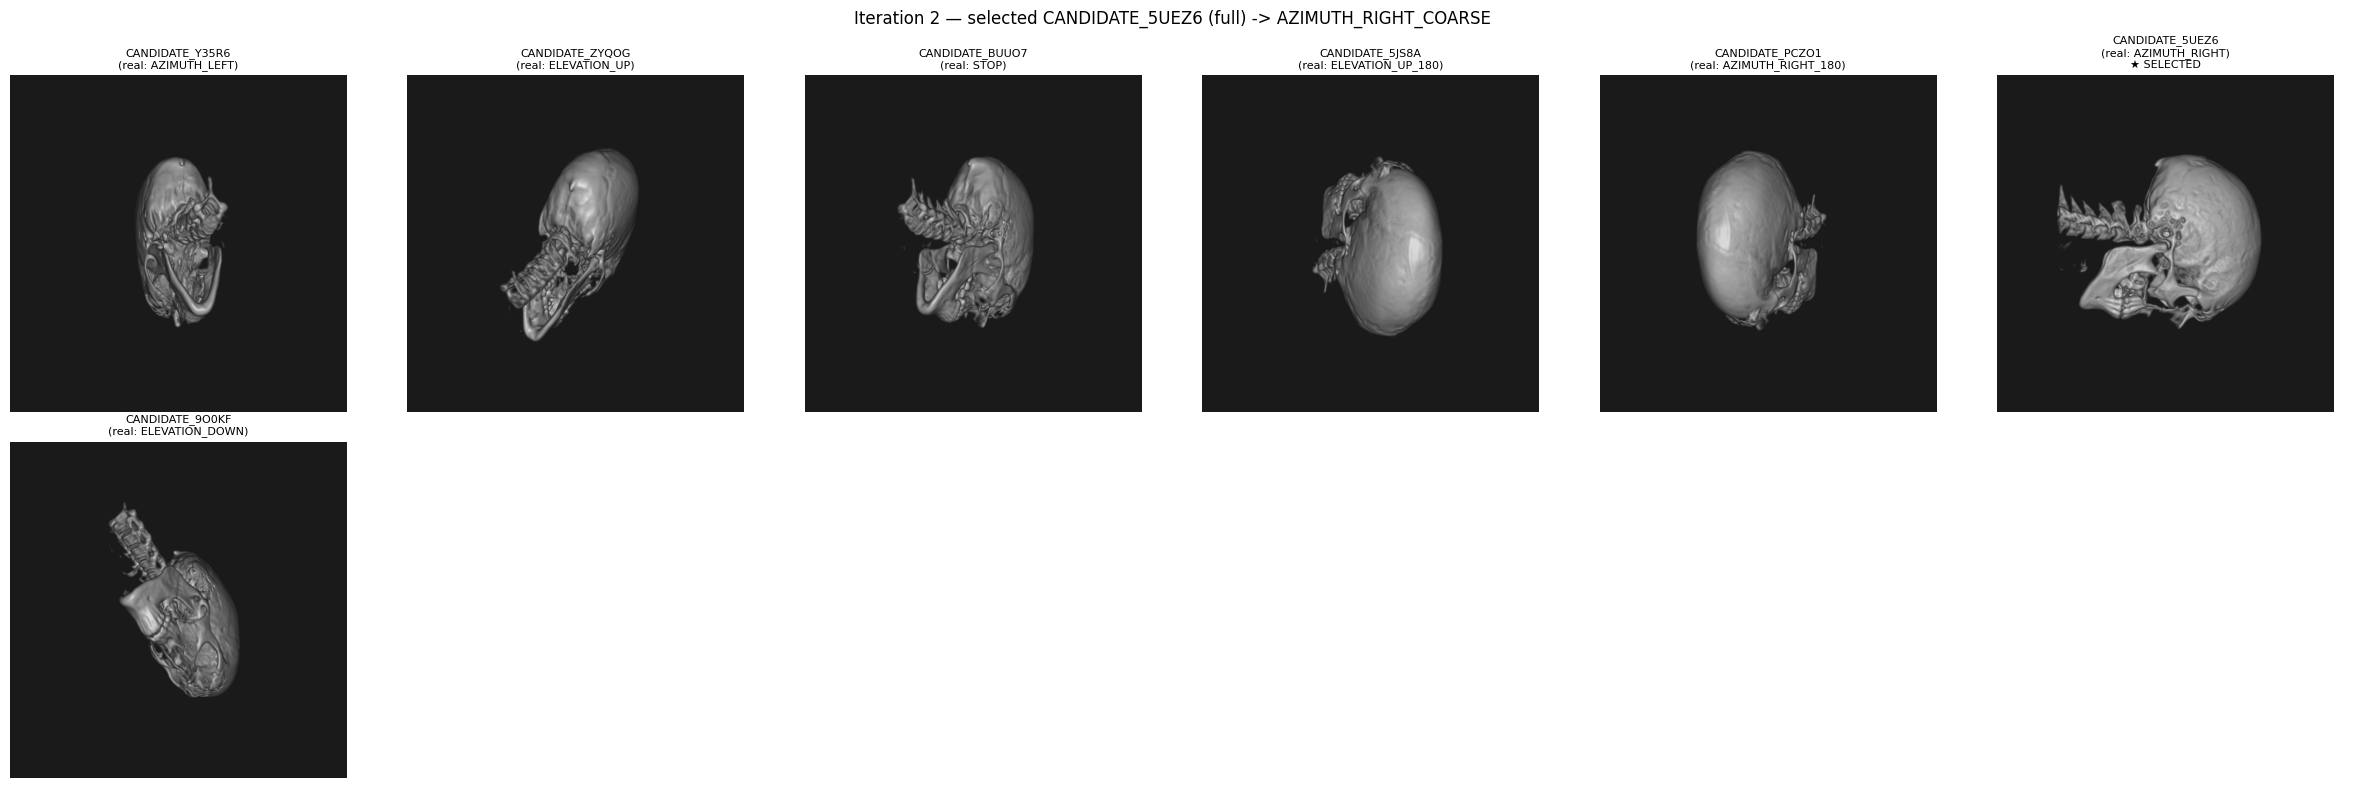


[blind_visual_rollout_agent] Iteration 3
[blind_visual_rollout_agent] Prepared 7 blind candidates (shuffled, private mapping not logged): ['CANDIDATE_H33Q7', 'CANDIDATE_341EL', 'CANDIDATE_6878L', 'CANDIDATE_QHLQU', 'CANDIDATE_1R2HO', 'CANDIDATE_FSCKF', 'CANDIDATE_PZ9SW']
[blind_visual_rollout_agent] PASS 1 — VISUAL DIAGNOSIS
```json
{
  "target": {
    "view_description": "The target shows a human skull in right-side profile. The right lateral surface of the cranium dominates the view, with the temporal bone, zygomatic arch, and mastoid process clearly visible. The right side of the mandible and maxilla are seen, showing the full dental arcade from this lateral perspective. The face is oriented to the left of the frame, with the posterior cranium to the right.",
    "closest_reference_id": "skull_001",
    "reference_match_quality": "exact",
    "reference_match_differences": "No meaningful difference observed; both show the same right lateral profile view with identical orientation a

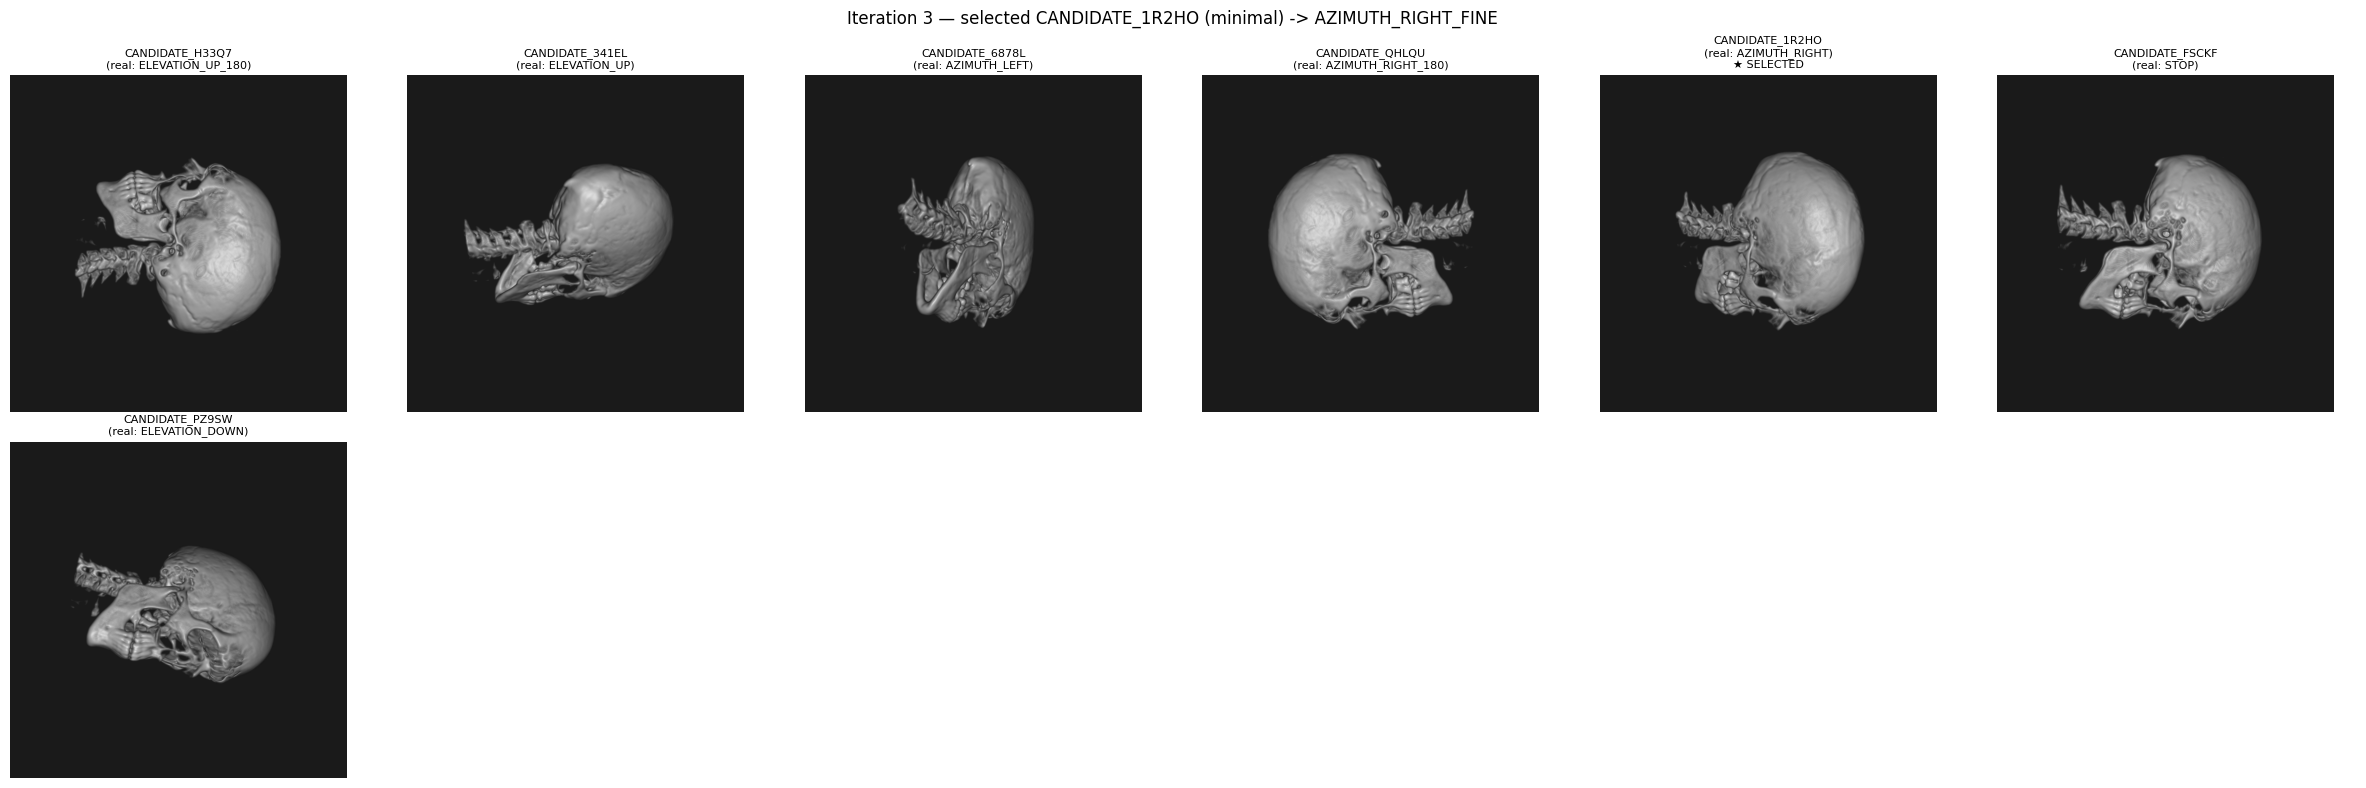


[blind_visual_rollout_agent] Iteration 4
[blind_visual_rollout_agent] Prepared 7 blind candidates (shuffled, private mapping not logged): ['CANDIDATE_MH397', 'CANDIDATE_2HMT7', 'CANDIDATE_3SQFH', 'CANDIDATE_E826H', 'CANDIDATE_RPNAL', 'CANDIDATE_QGDHY', 'CANDIDATE_ILPAR']
[blind_visual_rollout_agent] PASS 1 — VISUAL DIAGNOSIS
```json
{
  "target": {
    "view_description": "The target shows a human skull in right-side profile. The facial surface (maxilla, nasal opening, orbit) is visible on the left side of the image, the cranial vault dominates the center and right, and the teeth and mandible are visible below. The lateral surface of the skull is fully exposed, with the zygomatic arch visible in the middle, and the mastoid process and occipital region visible posteriorly.",
    "closest_reference_id": "skull_001",
    "reference_match_quality": "exact",
    "reference_match_differences": "No meaningful difference observed. The target viewpoint matches the right lateral profile shown i

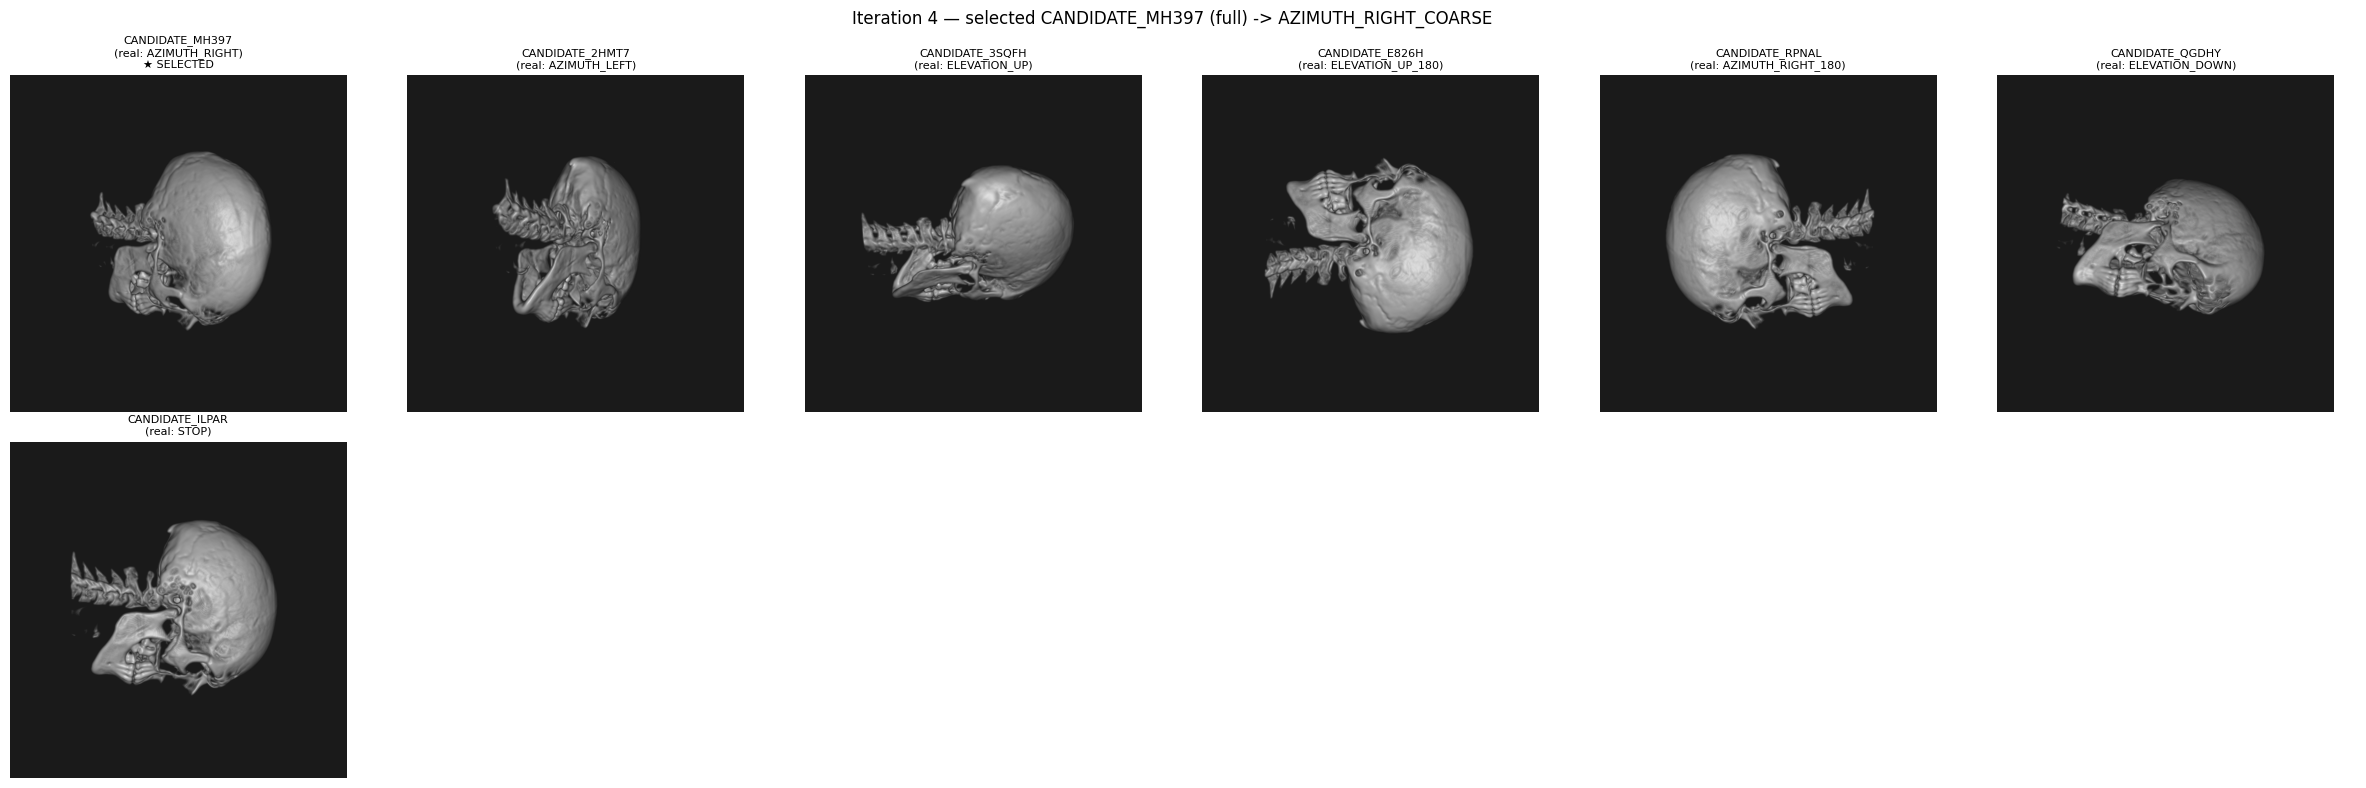


[blind_visual_rollout_agent] Iteration 5
[blind_visual_rollout_agent] Prepared 7 blind candidates (shuffled, private mapping not logged): ['CANDIDATE_T8RNR', 'CANDIDATE_O9FGZ', 'CANDIDATE_AL5YK', 'CANDIDATE_GLB5F', 'CANDIDATE_G26IP', 'CANDIDATE_Y7EYP', 'CANDIDATE_CMXDC']
[blind_visual_rollout_agent] PASS 1 — VISUAL DIAGNOSIS
```json
{
  "target": {
    "view_description": "The target shows a human skull in right-side lateral profile. The right lateral surface of the cranium dominates the view, with the facial skeleton visible from the side including the zygomatic arch, maxilla, and mandible. The teeth are visible in profile, and the temporal bone region, orbit, and nasal aperture are seen from the lateral aspect. The skull is oriented with the facial structures pointing to the left of frame and the posterior cranium to the right.",
    "closest_reference_id": "skull_001",
    "reference_match_quality": "exact",
    "reference_match_differences": "No meaningful difference observed; bot

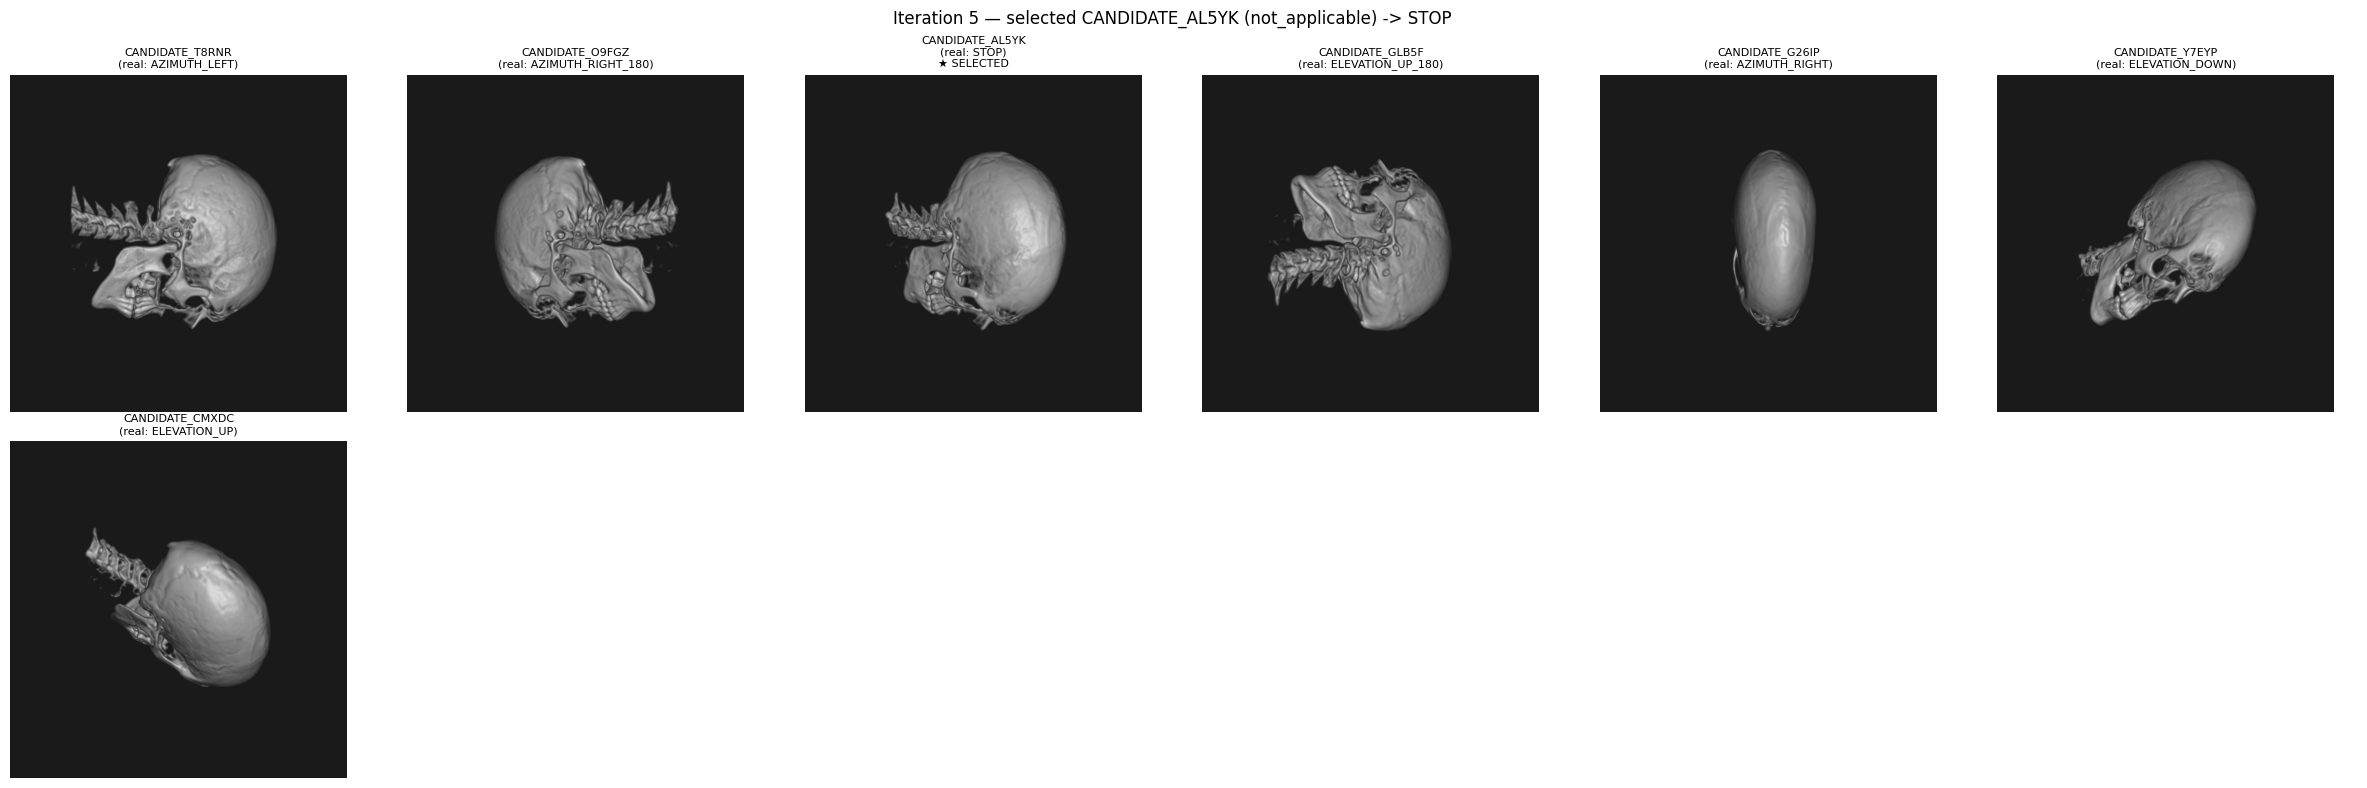

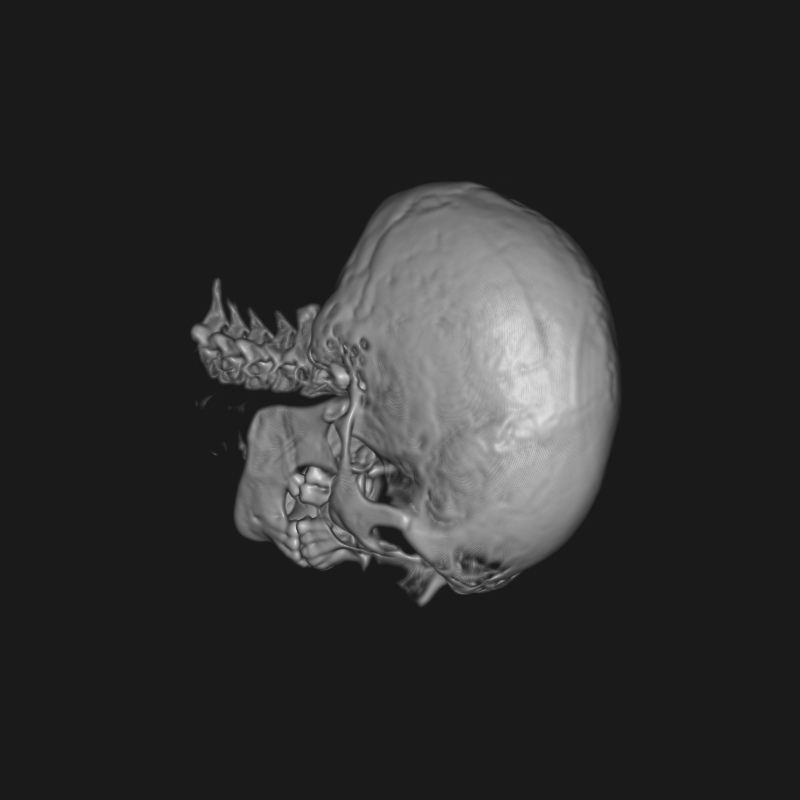


Applied actions: ['AZIMUTH_LEFT_MEDIUM', 'AZIMUTH_RIGHT_COARSE', 'AZIMUTH_RIGHT_COARSE', 'AZIMUTH_RIGHT_FINE', 'AZIMUTH_RIGHT_COARSE', 'STOP']


In [35]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from camera_reasoning.blind_visual_rollout_agent import run_blind_visual_rollout_alignment_loop

def display_blind_candidates(trace_path: str):
    """Show every blind candidate image from one iteration's trace, labeled with
    the opaque candidate ID — exactly what the LLM saw. The real resolved action
    is also shown in parentheses for YOUR debugging only; the LLM itself never
    sees it. The selected candidate is marked.

    Reads the three-pass trace schema: pass_2_deterministic_selection holds the
    Python-selected candidate (never the LLM's own "selection"), and
    pass_3_magnitude_estimation holds the magnitude decided for it.
    """
    trace = json.loads(open(trace_path).read())
    candidates = trace["blind_candidates"]
    mapping = trace["private_candidate_mapping"]
    selection = trace["pass_2_deterministic_selection"]
    magnitude = trace["pass_3_magnitude_estimation"]["parsed"]
    selected_candidate = selection.get("selected_candidate")

    n = len(candidates)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, c in enumerate(candidates):
        img = mpimg.imread(c["image_path"])
        axes[i].imshow(img)
        axes[i].axis("off")
        real_action = mapping.get(c["candidate_id"], "?")
        marker = "\n★ SELECTED" if c["candidate_id"] == selected_candidate else ""
        axes[i].set_title(f"{c['candidate_id']}\n(real: {real_action}){marker}", fontsize=8)
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"Iteration {trace['iteration']} — selected {selected_candidate} "
        f"({magnitude.get('magnitude_recommendation')}) -> {trace['final_action']}"
    )
    plt.tight_layout()
    plt.show()

# Reference bank: reference_views_medical/skull/ instead of reference_views_relative/.
# This bank has no camera_graph.json / CameraSpatialGraph at all — it's a flat set of
# real medical reference photos (3 base views x 8 in-plane roll variants each (0/45/90/.../315 degrees) = 24
# images). Using the SIMPLE label mapping here (reference_views_simple.json — see
# camera_reasoning/simple_reference_labels.py and
# examples/generate_simple_reference_labels.py): just {node_id: label}, e.g.
# "anterior", "right_rot045", etc. — instead of the full landmark/relations JSON
# (reference_views.json, still produced by the untouched medical_reference_views.py
# pipeline whenever you want the richer schema back).
_REFERENCE_BANK_DIR = Path("../reference_views_medical/skull")
_simple_labels = json.loads((_REFERENCE_BANK_DIR / "reference_views_simple.json").read_text())

reference_image_paths = {
    node_id: str(_REFERENCE_BANK_DIR / f"{node_id}.png")
    for node_id in _simple_labels
}
node_descriptions = dict(_simple_labels)
print(f"Loaded {len(reference_image_paths)} medical skull reference images and labels.")

blind_result = run_blind_visual_rollout_alignment_loop(
    session,
    max_iterations=10,
    reference_image_paths=reference_image_paths,
    node_descriptions=node_descriptions,
    on_iteration_end=display_blind_candidates,
)

display(Image("../output/screenshots/latest.png"))
print("\nApplied actions:", blind_result["applied_actions"])

---
## Utilities

In [ ]:
# Manually apply an action without calling the OpenAI API
# session.process_chatgpt_response("Next action:\nAZIMUTH_RIGHT_MEDIUM")

# Or paste a ChatGPT reply you already have (e.g. from the web UI) and process it directly:
# chatgpt_response = """Next action:\nAZIMUTH_RIGHT_MEDIUM"""
# session.process_chatgpt_response(chatgpt_response)

In [ ]:
# Hard-reset the camera (destroys manual alignment)
# session.reset_camera()
# session.render_and_save()
# display(Image("../output/screenshots/latest.png"))

In [ ]:
# Restore camera from a saved state
# session.load_camera_state("../output/camera_states/step_003_ELEVATION_UP_MEDIUM.json")